# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    baseline_results[name] = (scores.mean(), scores.std())

for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)
columns_to_show = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']

top_10_svm = cv_results_df[columns_to_show].sort_values('rank_test_score').head(10)
display(top_10_svm)

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None] + list(range(2, 21)), 
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(
    estimator=base_models['RandomForest'],
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 7, 'max_features': 0.5, 'min_samples_split': 3, 'n_estimators': 219}
Лучший CV F1: 0.9576


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# Заполните таблицу:
print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)
print(f"{'Модель':<25} | {'CV F1 (mean±std)':<20} | {'Test F1':<10}")
print("-" * 70)

# SVM baseline
svm_baseline = base_models['SVM']
svm_baseline_scores = cross_val_score(svm_baseline, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
svm_baseline_test = f1_score(y_test, svm_baseline.fit(X_train, y_train).predict(X_test), average='macro')
print(f"{'SVM baseline':<25} | {svm_baseline_scores.mean():.4f} ± {svm_baseline_scores.std():.4f} | {svm_baseline_test:.4f}")

# SVM Grid Search
svm_gs_test = f1_score(y_test, svm_grid_search.predict(X_test), average='macro')
print(f"{'SVM Grid Search':<25} | {svm_grid_search.best_score_:.4f} ± {svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]:.4f} | {svm_gs_test:.4f}")

# RF baseline
rf_baseline = base_models['RandomForest']
rf_baseline_scores = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
rf_baseline_test = f1_score(y_test, rf_baseline.fit(X_train, y_train).predict(X_test), average='macro')
print(f"{'RF baseline':<25} | {rf_baseline_scores.mean():.4f} ± {rf_baseline_scores.std():.4f} | {rf_baseline_test:.4f}")

# RF Random Search
rf_rs_test = f1_score(y_test, rf_random_search.predict(X_test), average='macro')
print(f"{'RF Random Search':<25} | {rf_random_search.best_score_:.4f} ± {rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f} | {rf_rs_test:.4f}")

print("="*70)


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Модель                    | CV F1 (mean±std)     | Test F1   
----------------------------------------------------------------------
SVM baseline              | 0.9694 ± 0.0193 | 0.9812
SVM Grid Search           | 0.9786 ± 0.0176 | 0.9812
RF baseline               | 0.9504 ± 0.0255 | 0.9526
RF Random Search          | 0.9576 ± 0.0193 | 0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

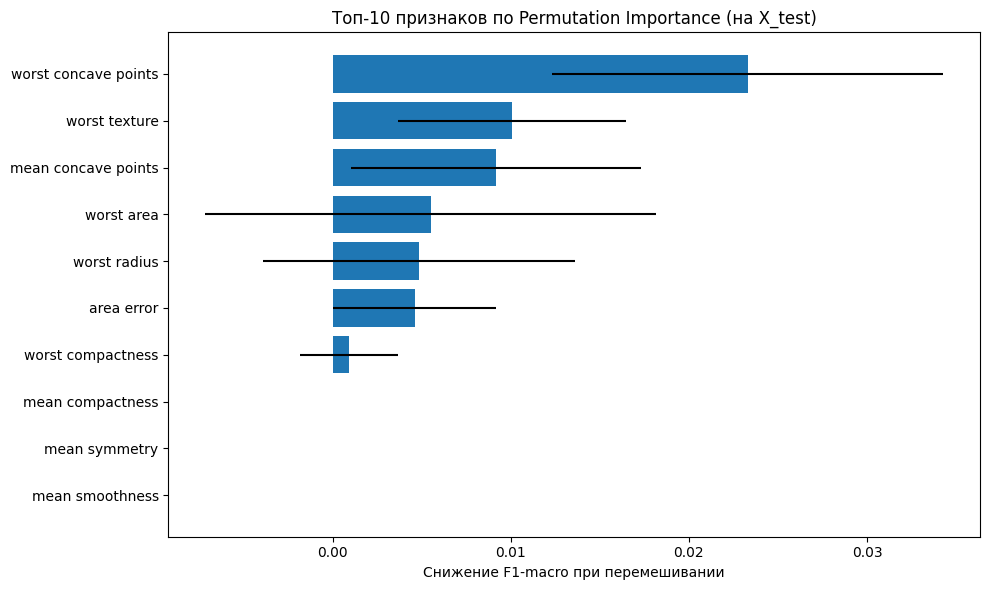

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

pi_result = permutation_importance(
    best_rf, X_test, y_test, 
    n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1
)

# Собираем DataFrame для удобства
pi_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': pi_result.importances_mean,
    'importance_std': pi_result.importances_std
}).sort_values('importance_mean', ascending=False)

# Bar plot топ-10 признаков
top_10_pi = pi_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_pi['feature'][::-1], top_10_pi['importance_mean'][::-1], xerr=top_10_pi['importance_std'][::-1])
plt.title("Топ-10 признаков по Permutation Importance (на X_test)")
plt.xlabel("Снижение F1-macro при перемешивании")
plt.tight_layout()
plt.show()

In [9]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-5 признаков по PI:")
print(pi_df['feature'].head(5).values)

print("\nТоп-5 признаков по Gini:")
print(fi_df['feature'].head(5).values)

Топ-5 признаков по PI:
<StringArray>
['worst concave points',        'worst texture',  'mean concave points',
           'worst area',         'worst radius']
Length: 5, dtype: str

Топ-5 признаков по Gini:
<StringArray>
[     'worst perimeter', 'worst concave points',           'worst area',
         'worst radius',  'mean concave points']
Length: 5, dtype: str


Разница возникает потому, что Gini вычисляется на train и часто отдает предпочтение непрерывным признакам с высокой кардинальностью. 

PI вычисляется на тестовых данных, поэтому лучше отражает реальную обобщающую способность признака.

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

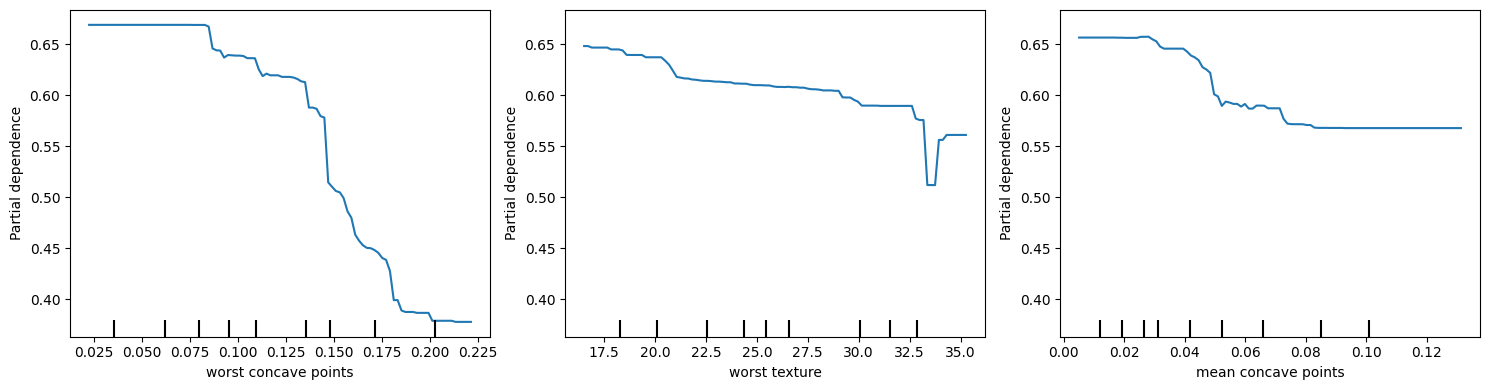

In [10]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = pi_df['feature'].head(3).tolist()

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, features=top3_idx, kind='average', ax=ax
)
plt.tight_layout()
plt.show()

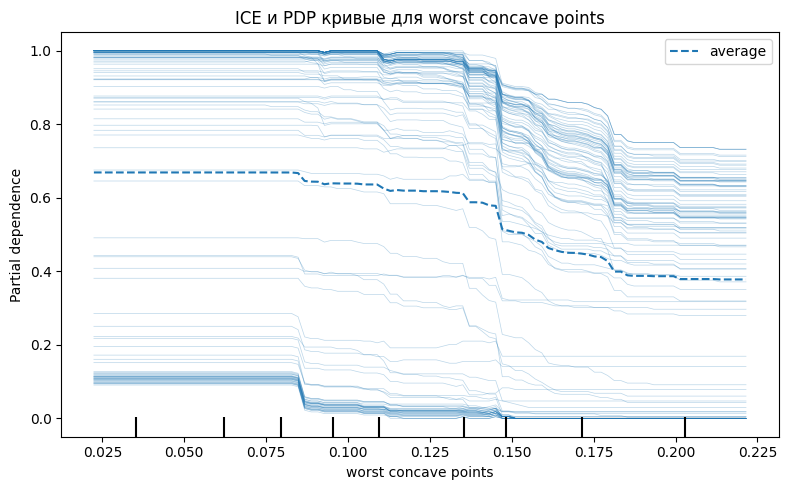

In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

top1_feature = top3_idx[0]

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, features=[top1_feature], kind='both', ax=ax
)
plt.title(f"ICE и PDP кривые для {top1_feature}")
plt.tight_layout()
plt.show()

Эффект не однороден.

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝
shap.initjs()

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test.values)
print(f"Форма shap_values: {np.array(shap_values).shape}")

Форма shap_values: (114, 30, 2)


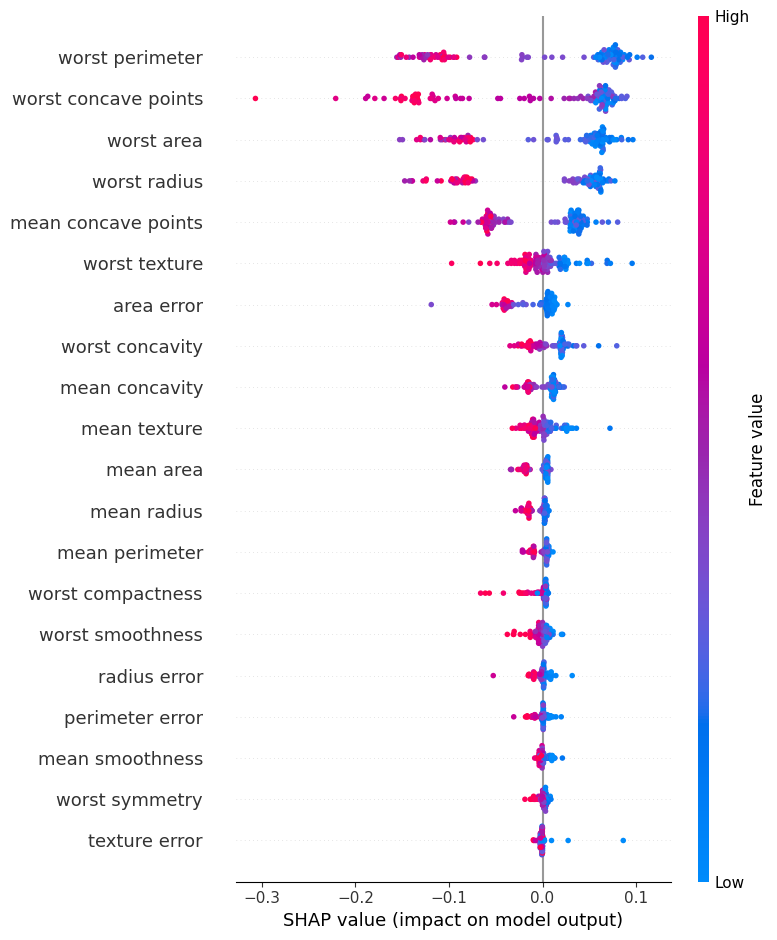

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

shap.summary_plot(shap_values[:, :, 1], X_test.values, feature_names=feature_names)

1. Самые важные признаки по SHAP:
- worst perimeter
- worst concave points
- worst area
- worst radius
- mean concave points

2. Важные признаки SHAP совпадают с топом по Permutation Importance, за исключением worst perimeter.

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


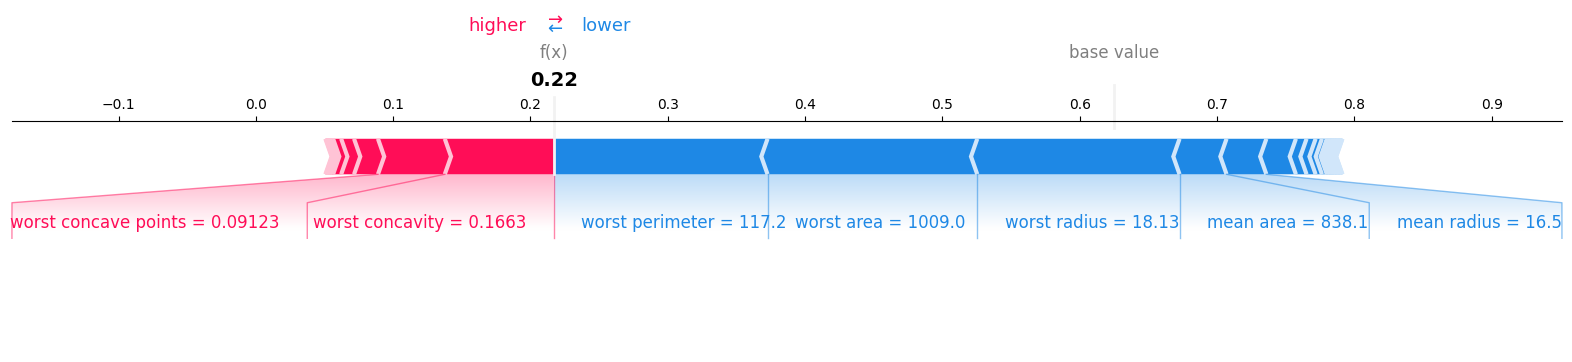

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"Истинный класс: {y_test.iloc[errors[0]]}")
print(f"Предсказанный класс: {y_pred_test[errors[0]]}")

error_idx = errors[0]

shap_values_class1_sample = shap_values[error_idx, :, 1]
X_test_sample = X_test.iloc[error_idx, :]

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1_sample,
    X_test_sample,
    matplotlib=True
)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [15]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Топ-5 признаков по PI (с утечкой):
            feature  importance
30    leaky_feature    0.503274
0       mean radius    0.000000
2    mean perimeter    0.000000
1      mean texture    0.000000
4   mean smoothness    0.000000


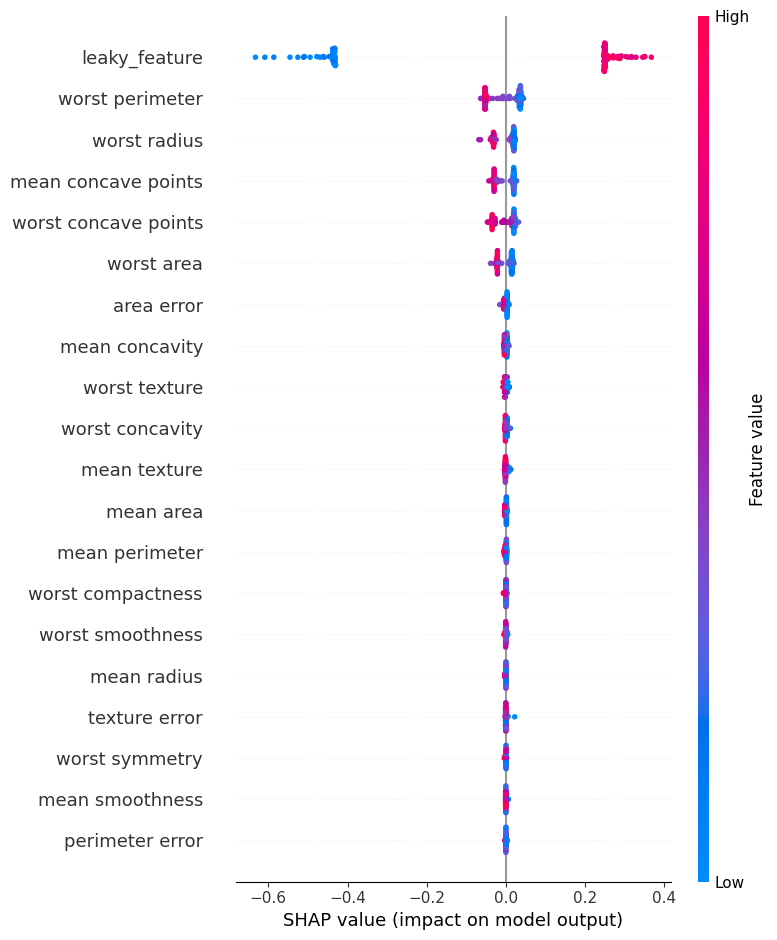

In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

rf_ext = RandomForestClassifier(random_state=42, **rf_random_search.best_params_)
rf_ext.fit(X_train_ext, y_train)

pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test, 
    n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1
)
pi_ext_df = pd.DataFrame({
    'feature': X_test_ext.columns, 
    'importance': pi_ext.importances_mean
}).sort_values('importance', ascending=False)

print("Топ-5 признаков по PI (с утечкой):")
print(pi_ext_df.head())

X_test_ext_array = X_test_ext.values

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext_array)

shap_values_for_class = shap_values_ext[:, :, 1]

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_for_class, 
    X_test_ext_array, 
    feature_names=X_test_ext.columns.tolist()
)

а) PI ставит leaky_feature на первое место по важности. Точность выросла почти до 1.0, потому что модель запонмила ответ из этого признака.

б) На SHAP summary plot значения leaky_feature оказывают самое сильное влияние на предсказание.

в) Перемешивание случайного шума никак не ухудшает качество.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# Собираем сводную таблицу результатов
summary_rows = []

# SVM baseline (из baseline_results)
svm_cv_mean, svm_cv_std = baseline_results['SVM']
summary_rows.append({
    'Model': 'SVM baseline',
    'CV F1 (mean)': svm_cv_mean,
    'CV F1 (std)': svm_cv_std,
    'Test F1': svm_baseline_test
})

# SVM Grid Search
svm_gs_cv_mean = svm_grid_search.best_score_
svm_gs_cv_std = svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]
summary_rows.append({
    'Model': 'SVM Grid Search',
    'CV F1 (mean)': svm_gs_cv_mean,
    'CV F1 (std)': svm_gs_cv_std,
    'Test F1': svm_gs_test
})

# RF baseline
rf_cv_mean, rf_cv_std = baseline_results['RandomForest']
summary_rows.append({
    'Model': 'RF baseline',
    'CV F1 (mean)': rf_cv_mean,
    'CV F1 (std)': rf_cv_std,
    'Test F1': rf_baseline_test
})

# RF Random Search
rf_rs_cv_mean = rf_random_search.best_score_
rf_rs_cv_std = rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]
summary_rows.append({
    'Model': 'RF Random Search',
    'CV F1 (mean)': rf_rs_cv_mean,
    'CV F1 (std)': rf_rs_cv_std,
    'Test F1': rf_rs_test
})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index('Model')
display(summary_df.round(4))


,CV F1 (mean),CV F1 (std),Test F1
Model,,,
SVM baseline,0.9694,0.0193,0.9812
SVM Grid Search,0.9786,0.0176,0.9812
RF baseline,0.9504,0.0255,0.9526
RF Random Search,0.9576,0.0193,0.9526


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

Лучший результат Optuna: 0.9576
Лучшие параметры: {'n_estimators': 230, 'max_depth': 20, 'min_samples_split': 3, 'max_features': 0.5}


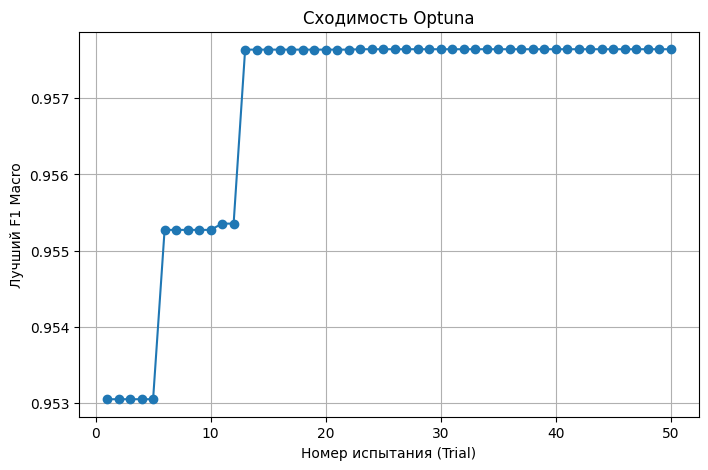

In [19]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_categorical('max_depth', [None] + list(range(2, 21))),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5])
    }
    
    model = RandomForestClassifier(random_state=42, **params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

best_values_over_time = np.maximum.accumulate([t.value for t in study.trials])

plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), best_values_over_time, marker='o')
plt.title("Сходимость Optuna")
plt.xlabel("Номер испытания (Trial)")
plt.ylabel("Лучший F1 Macro")
plt.grid(True)
plt.show()